<h1>Data Collection: Import Libraries </h1>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
%matplotlib inline
Titanic_data = pd.read_csv('Titanic.csv')


In [2]:
Titanic_data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
print("number of passengers in orginal data:"+str(len(Titanic_data.index)))

number of passengers in orginal data:91


<h1>Analyzing Data</h1>

<Axes: xlabel='Survived', ylabel='count'>

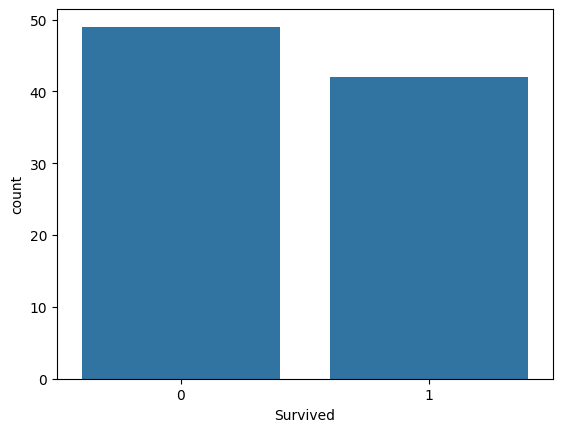

In [4]:
sns.countplot(x="Survived",data=Titanic_data)

<Axes: xlabel='Survived', ylabel='count'>

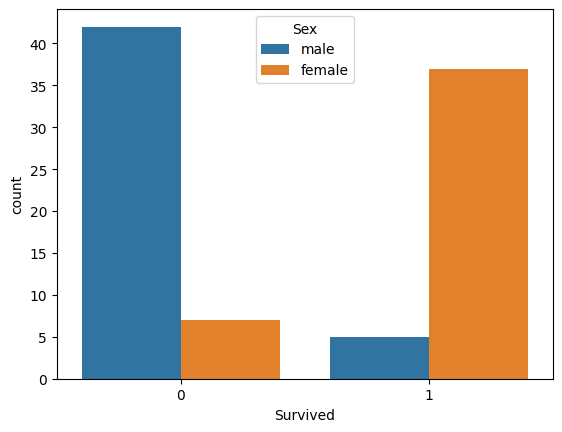

In [5]:
sns.countplot(x="Survived",hue="Sex",data=Titanic_data)

<Axes: xlabel='Survived', ylabel='count'>

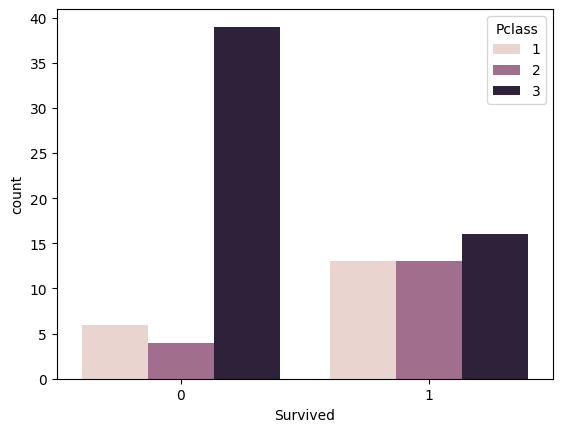

In [6]:
sns.countplot(x="Survived",hue="Pclass",data=Titanic_data)

<Axes: ylabel='Frequency'>

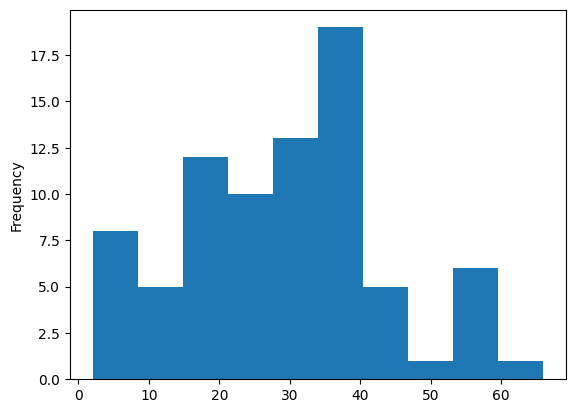

In [7]:
Titanic_data["Age"].plot.hist()

<Axes: ylabel='Frequency'>

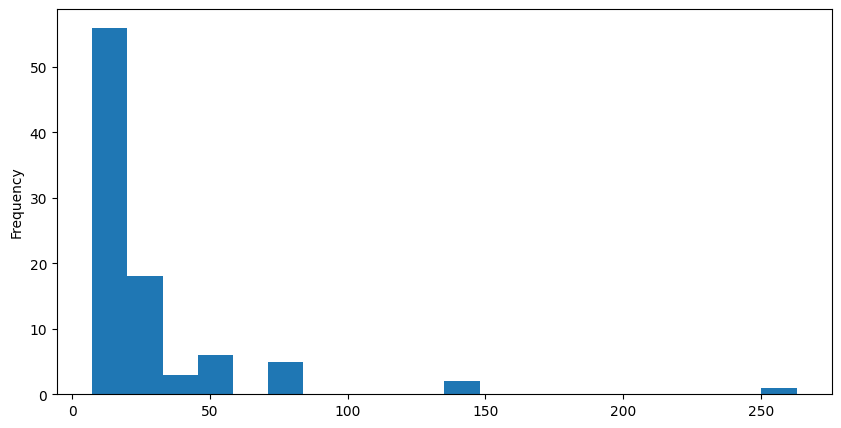

In [8]:
Titanic_data["Fare"].plot.hist(bins=20,figsize=(10,5))

In [9]:
Titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91 entries, 0 to 90
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  91 non-null     int64  
 1   Survived     91 non-null     int64  
 2   Pclass       91 non-null     int64  
 3   Name         91 non-null     object 
 4   Sex          91 non-null     object 
 5   Age          80 non-null     float64
 6   SibSp        91 non-null     int64  
 7   Parch        91 non-null     int64  
 8   Ticket       91 non-null     object 
 9   Fare         91 non-null     float64
 10  Cabin        19 non-null     object 
 11  Embarked     91 non-null     object 
dtypes: float64(2), int64(5), object(5)
memory usage: 8.7+ KB


<Axes: xlabel='SibSp', ylabel='count'>

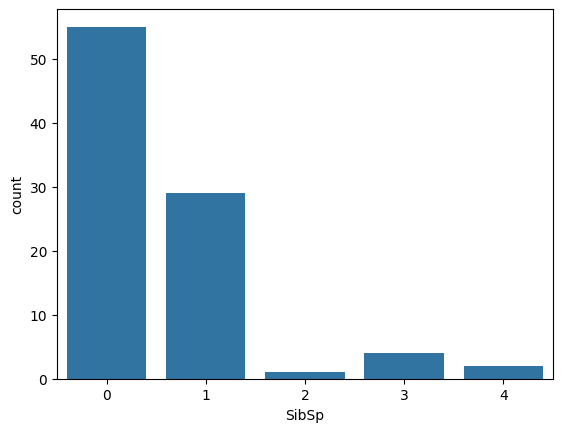

In [10]:
sns.countplot(x="SibSp",data=Titanic_data)

<h1>Data Wranglings</h1>

In [11]:
Titanic_data.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
86,False,False,False,False,False,False,False,False,False,False,True,False
87,False,False,False,False,False,False,False,False,False,False,True,False
88,False,False,False,False,False,False,False,False,False,False,False,False
89,False,False,False,False,False,False,False,False,False,False,True,False


In [12]:
Titanic_data.isnull().sum()

PassengerId     0
Survived        0
Pclass          0
Name            0
Sex             0
Age            11
SibSp           0
Parch           0
Ticket          0
Fare            0
Cabin          72
Embarked        0
dtype: int64

<Axes: >

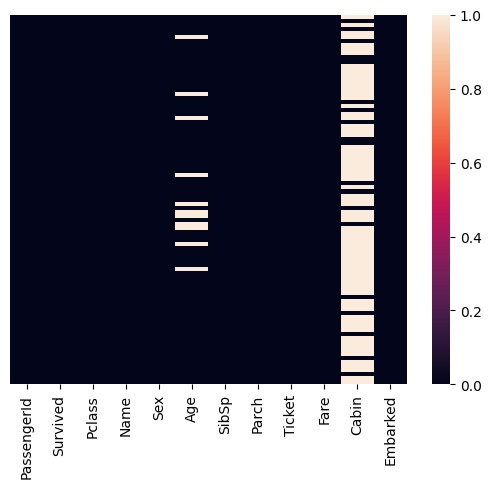

In [13]:
sns.heatmap(Titanic_data.isnull(), yticklabels=False)

<Axes: xlabel='Pclass', ylabel='Age'>

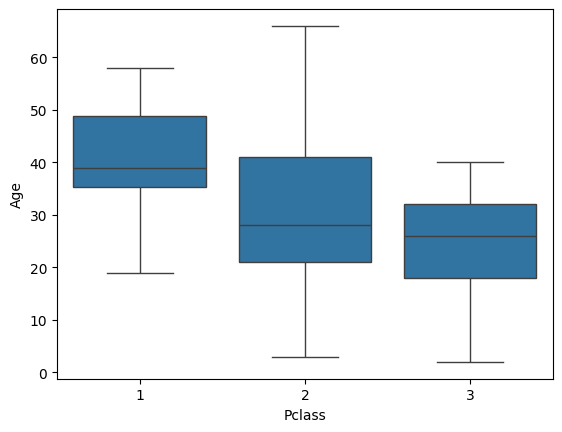

In [14]:
sns.boxplot(x='Pclass',y='Age',data=Titanic_data)

In [15]:
Titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [16]:
Titanic_data.drop("Cabin",axis=1,inplace=True)

In [17]:
Titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [18]:
Titanic_data.dropna(inplace=True)

<Axes: >

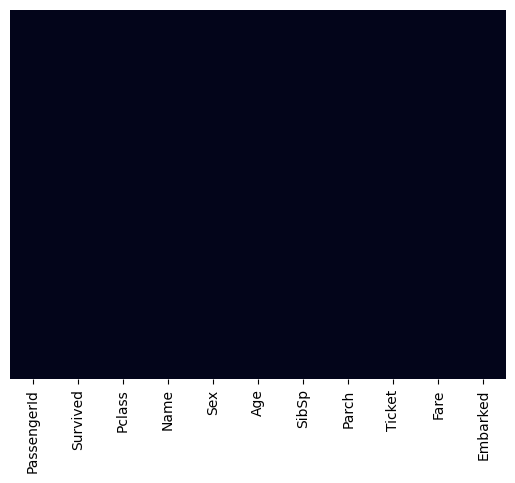

In [19]:
sns.heatmap(Titanic_data.isnull(),yticklabels=False,cbar=False)

In [20]:
Titanic_data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [21]:
Titanic_data.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley",female,38.0,1,0,PC 17599,71.2833,C


In [22]:
pd.get_dummies(Titanic_data['Sex'])

,female,male
0,False,True
1,True,False
2,True,False
3,True,False
4,False,True
...,...,...
86,True,False
87,False,True
88,True,False
89,False,True


In [23]:
sex=pd.get_dummies(Titanic_data['Sex'],drop_first=True)

In [24]:
sex.head()

,male
0,True
1,False
2,False
3,False
4,True


In [25]:
embark = pd.get_dummies(Titanic_data["Embarked"])
embark.head()

,C,Q,S
0,False,False,True
1,True,False,False
2,False,False,True
3,False,False,True
4,False,False,True


In [26]:
Pclass = pd.get_dummies(Titanic_data["Pclass"],drop_first=True)
Pclass.head()

,2,3
0,False,True
1,False,False
2,False,True
3,False,False
4,False,True


In [27]:
Titanic_data = pd.concat([Titanic_data,sex,embark,Pclass],axis=1)

In [28]:
Titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,male,C,Q,S,2,3
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,True,False,False,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley",female,38.0,1,0,PC 17599,71.2833,C,False,True,False,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,False,False,False,True,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath",female,35.0,1,0,113803,53.1000,S,False,False,False,True,False,False
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,True,False,False,True,False,True


In [29]:
Titanic_data.drop(['Sex','Embarked','PassengerId','Name','Ticket'],axis=1,inplace=True)

In [30]:
Titanic_data.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,male,C,Q,S,2,3
0,0,3,22.0,1,0,7.2500,True,False,False,True,False,True
1,1,1,38.0,1,0,71.2833,False,True,False,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,False,True,False,True
3,1,1,35.0,1,0,53.1000,False,False,False,True,False,False
4,0,3,35.0,0,0,8.0500,True,False,False,True,False,True


In [31]:
Titanic_data.drop('Pclass',axis=1,inplace=True)

In [32]:
Titanic_data.head()

,Survived,Age,SibSp,Parch,Fare,male,C,Q,S,2,3
0,0,22.0,1,0,7.2500,True,False,False,True,False,True
1,1,38.0,1,0,71.2833,False,True,False,False,False,False
2,1,26.0,0,0,7.9250,False,False,False,True,False,True
3,1,35.0,1,0,53.1000,False,False,False,True,False,False
4,0,35.0,0,0,8.0500,True,False,False,True,False,True


<h1>Train Data</h1>

In [33]:
x = Titanic_data.drop("Survived",axis=1)
y = Titanic_data["Survived"]

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3, random_state=1)

In [36]:
from sklearn.linear_model import LogisticRegression

In [38]:
logmodel=LogisticRegression()

In [40]:
x_train.columns = x_train.columns.astype(str)
x_test.columns = x_test.columns.astype(str)

logmodel.fit(x_train, y_train)

C:\Users\Lokendra Bhat\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [41]:
predictions = logmodel.predict(x_test)

In [43]:
from sklearn.metrics import classification_report

In [44]:
classification_report(y_test, predictions)

'              precision    recall  f1-score   support\n\n           0       0.85      0.92      0.88        12\n           1       0.91      0.83      0.87        12\n\n    accuracy                           0.88        24\n   macro avg       0.88      0.88      0.87        24\nweighted avg       0.88      0.88      0.87        24\n'

In [45]:
from sklearn.metrics import confusion_matrix

In [46]:
confusion_matrix(y_test,predictions)

array([[11,  1],
       [ 2, 10]])

<h1>Accuracy Check</h1>

In [47]:
from sklearn.metrics import accuracy_score

In [50]:
accuracy_score(y_test, predictions)

0.875